# TKO_7092 Evaluation of Machine Learning Methods 2026

## Exercise 3

---

Student name: Talha Rizwan

Student number: 2509714

Student email: tarizw@utu.fi

---

## IMPORTANT

This exercise involves using AI. Use only the *Study Chat* service provided by the University of Turku at [https://ai.utu.fi/en](https://ai.utu.fi/en). **Do not use any other AI service!** Before starting, remember to carefully read the guidelines for using AI ([https://intranet.utu.fi/en/sites/ai/guidelines/Pages/default.aspx](https://intranet.utu.fi/en/sites/ai/guidelines/Pages/default.aspx)) and the terms of use. **Do not share any personal information or copyrighted material with AI.**

Save all your discussions (including your prompts and AI's output) as well as the name of the model you used.

## Instructions

The deadline of this exercise is **Wednesday 18 February 2026 at 11:59 PM**. Please contact Juho Heimonen (juaheim@utu.fi) if you have any questions about the exercise. Remember to follow all the general exercise guidelines that are stated in Moodle.

The exercise has several parts, all of which concern the letter below. You will take the role of a data scientist who has been assigned to solve the problem described in the letter. You have an AI tool to assist you, but you alone are responsible for the quality of the solution.

#### 1

Ask AI to write code to solve the task. Analyse which parts of the AI-generated code are correct and which are incorrect. Pay particular attention to the key parts of the cross-validation. You may ask AI to improve the code as many times as you like, as long as you keep analysing its output.

#### 2

Implement the required leave-one-out cross-validations and run your code to get the estimates you were asked to obtain. Here it is okay to use any amount of the AI-generated code you produced above. You can use a complete, fully correct AI-written solution, you can write the implementation from scratch by yourself, or you can take some AI-generated code and complete the implementation manually.

#### 3

Write a report in which you discuss the following:

- Why did the cross-validation described in the letter fail? What is the correct way to do cross-validation here?

- Which parts of the task was AI able to code correctly and which not? Focus particularly on the core of the cross-validation.

- Which parts of the AI-generated code did you use in your implementation? Why? Explain why the selected pieces of code work correctly in your implementation.

- What results did you get with your implementation? Report the estimates and interpret the results in terms of how well the model will work in the situations described in the letter. Explain in detail why your cross-validation is the correct way to estimate the generalisation performance.

Write the report in your own words and explain everything clearly, precisely, and comprehensively. **You are not allowed to use AI to write the report for you** because this is where you show that you have understood the theory and are able to apply it. If you use AI as a teacher (i.e. to explain things to you for learning purposes), you must attach the discussions and clearly state what and how you learnt from the AI. **If there is uncertainty about how the text was produced, you may be required to explain the content of your report in a face-to-face meeting.**

#### 4

Submit the following documents to Moodle:

- The discussions with AI (including your prompts and AI's output), as PDF.

- The implementation of your cross-validation, as PDF and as a Jupyter notebook.

- The report, as PDF. (It is okay to integrate the report to the Jupyter notebook.)

Note that it is not enough to just implement the cross-validation correctly to pass this exercise. You must also explain in plain words what you have done and demonstrate that you understand how cross-validation should be performed on pair-input data. Small errors are acceptable, but you will fail this exercise if there are significant error(s) or omission(s) in the report or in the implementation.

## Letter from your client

Dear Data Scientist,

I have a long-term research project regarding a specific set of proteins. I am attempting to discover small organic compounds that can bind strongly to these proteins and thus act as drugs. I have already made laboratory experiments to measure the affinities between some proteins and drug molecules.

My colleague is working on another set of proteins, and the objectives of his project are similar to mine. He has recently discovered thousands of new potential drug molecules. He asked me if I could find the pairs that have the strongest affinities among his proteins and drug molecules. Obviously I do not have the resources to measure all the possible pairs in my laboratory, so I need to prioritise. I decided to do this with the help of machine learning, but I have encountered a problem.

Here is what I have done so far: First I trained a K-nearest neighbours regressor with the parameter value K=10 using all the 400 measurements I had already made in the laboratory with my proteins and drug molecules. They comprise of 77 target proteins and 59 drug molecules. To estimate the generalisation performance of the model, I then performed a leave-one-out cross-validation. I used C-index and got a stellar score above 90%. Finally I used the model to predict the affinities of my colleague's proteins and drug molecules. The problem is that when I selected the highest predicted affinities and my colleague tried to verify them in the lab, we found that many of them are much lower in reality. My model clearly does not work despite the high cross-validation score. We also tested the model with my proteins against my colleague's drugs (which is another task I would like to use my model for), but the model did not work there either.

Please explain why my estimation failed and how leave-one-out cross-validation should be performed to get reliable estimates. Also, please implement the leave-one-out cross-validation correctly and report the numbers I need. I want to know whether it would be a waste of my colleague's and my resources if we were to use my model any further.

The data I used to create my model is available in the files `input.data`, `output.data` and `pairs.data` for you to use. The first file contains the features of the pairs, whereas the second contains their affinities. The third file contains the identifiers of the drug and target molecules of which the pairs are composed. The files are paired, i.e. the i<sup>*th*</sup> row in each file is about the same pair.

Looking forward to hearing from you soon.

Yours sincerely, \
Bio Scientist


## Part 1: AI-generated baseline code (Mistral Devstral 2)

Below is the baseline implementation from Mistral Dev.

In [15]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt

# Custom function to calculate C-index
def c_index(y_true, y_pred):
    """
    Calculate the concordance index (C-index) for evaluating prediction performance.

    Parameters:
    y_true (array-like): True target values
    y_pred (array-like): Predicted target values

    Returns:
    float: C-index score (between 0 and 1, higher is better)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    concordant = 0
    permissible = 0

    for i in range(len(y_true)):
        for j in range(i + 1, len(y_true)):
            if y_true[i] != y_true[j]:
                permissible += 1
                if (y_pred[i] > y_pred[j] and y_true[i] > y_true[j]) or \
                   (y_pred[i] < y_pred[j] and y_true[i] < y_true[j]):
                    concordant += 1

    if permissible == 0:
        return 0.0

    return concordant / permissible

In [17]:
# 1. Load and preprocess the data
def load_and_preprocess_data(input_file, output_file, pairs_file):
    """
    Load and preprocess the dataset.

    Parameters:
    input_file (str): Path to input features file
    output_file (str): Path to output affinities file
    pairs_file (str): Path to pairs identifiers file

    Returns:
    tuple: (X, y, pairs_df) where X is features, y is targets, pairs_df contains identifiers
    """
    X = pd.read_csv(input_file, header=None, sep=r"\s+").values
    y = pd.read_csv(output_file, header=None, sep=r"\s+").values.ravel()
    pairs_df = pd.read_csv(
        pairs_file,
        header=None,
        names=['drug_id', 'protein_id'],
        sep=r"\s+",
        quotechar='"'
    )

    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_std[X_std == 0] = 1.0
    X = (X - X_mean) / X_std

    return X, y, pairs_df

In [18]:
# 2. Train KNN regressor with K=10 and perform LOOCV
def knn_loocv_with_cindex(X, y, k=10):
    """
    Perform leave-one-out cross-validation with KNN regressor and evaluate using C-index.

    Parameters:
    X (array-like): Input features
    y (array-like): Target values
    k (int): Number of neighbors for KNN

    Returns:
    tuple: (predictions, c_index_score)
    """
    knn = KNeighborsRegressor(n_neighbors=k)
    loo = LeaveOneOut()

    predictions = np.zeros_like(y)

    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train = y[train_index]

        knn.fit(X_train, y_train)
        predictions[test_index] = knn.predict(X_test)

    c_index_score = c_index(y, predictions)
    return predictions, c_index_score

In [19]:
# 3. Visualization functions
def plot_true_vs_predicted(y_true, y_pred):
    """
    Plot true vs predicted values.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    plt.xlabel('True Affinity')
    plt.ylabel('Predicted Affinity')
    plt.title('True vs Predicted Affinity Values')
    plt.grid(True)
    plt.show()


def plot_residuals(y_true, y_pred):
    """
    Plot residuals (errors) of predictions.
    """
    residuals = y_true - y_pred
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='-')
    plt.xlabel('Predicted Affinity')
    plt.ylabel('Residuals (True - Predicted)')
    plt.title('Residual Plot')
    plt.grid(True)
    plt.show()

In [20]:
# 4. Main execution
input_file = 'input.data'
output_file = 'output.data'
pairs_file = 'pairs.data'

X, y, pairs_df = load_and_preprocess_data(input_file, output_file, pairs_file)
print(f"Data loaded. Features shape: {X.shape}, Targets shape: {y.shape}")

predictions, c_index_score = knn_loocv_with_cindex(X, y, k=10)
print(f"C-index score: {c_index_score:.4f}")

Data loaded. Features shape: (400, 67), Targets shape: (400,)
C-index score: 0.8293


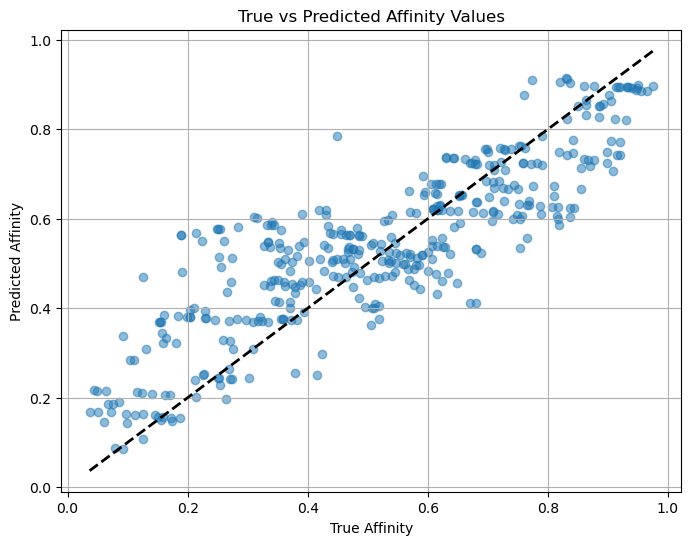

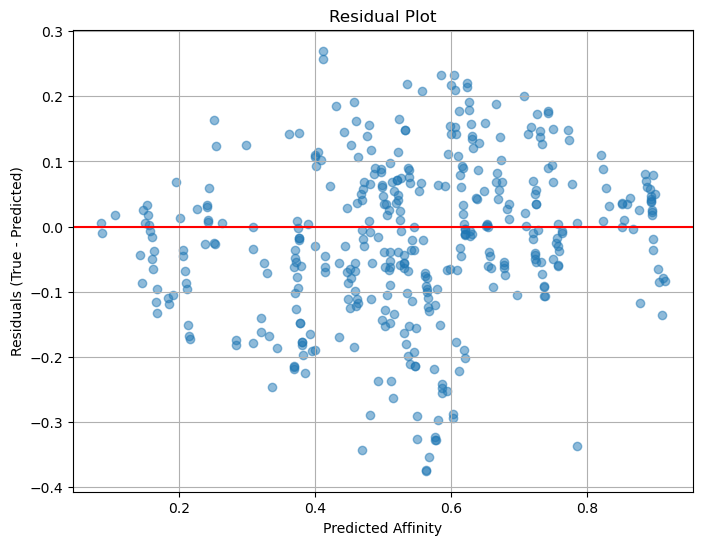

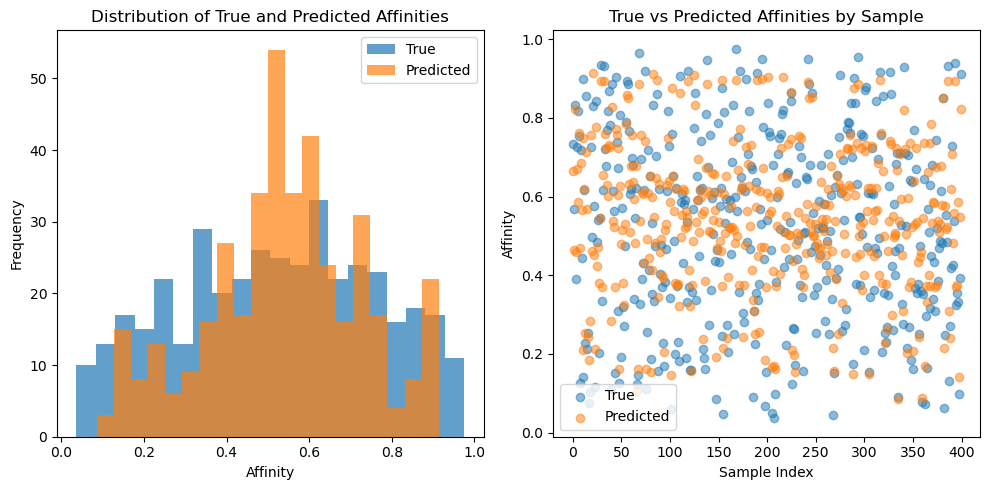

In [21]:
# 5. Plot results
plot_true_vs_predicted(y, predictions)
plot_residuals(y, predictions)

# Additional analysis: Distribution of predictions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(y, bins=20, alpha=0.7, label='True')
plt.hist(predictions, bins=20, alpha=0.7, label='Predicted')
plt.xlabel('Affinity')
plt.ylabel('Frequency')
plt.title('Distribution of True and Predicted Affinities')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(range(len(y)), y, label='True', alpha=0.5)
plt.scatter(range(len(predictions)), predictions, label='Predicted', alpha=0.5)
plt.xlabel('Sample Index')
plt.ylabel('Affinity')
plt.title('True vs Predicted Affinities by Sample')
plt.legend()
plt.tight_layout()
plt.show()

### Part 1 analysis of AI-generated code

The AI-generated code is partly correct and useful as a baseline: it correctly loads the three files, trains a KNN regressor with K=10, performs leave one out prediction over pairs, computes a C index like ranking score, and visualizes predictions and residuals clearly. However, the core validation logic is not correct for this assignment’s real deployment setting, because pair level leave one out allows the same drug or protein identities to appear in both training and test folds, which can produce overly optimistic performance estimates for new-molecule scenarios.

## Part 2: AI Generated Type D cross-validation (unseen drug - unseen target)

In [22]:
import numpy as np
import pandas as pd
import random
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Custom C-index function
def c_index(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    concordant = 0
    permissible = 0

    for i in range(len(y_true)):
        for j in range(i + 1, len(y_true)):
            if y_true[i] != y_true[j]:
                permissible += 1
                if (y_pred[i] > y_pred[j] and y_true[i] > y_true[j]) or \
                   (y_pred[i] < y_pred[j] and y_true[i] < y_true[j]):
                    concordant += 1

    return concordant / permissible if permissible > 0 else 0.0

In [23]:
# Load assignment data (.data files are whitespace-separated)
def load_data(input_file, output_file, pairs_file):
    X = pd.read_csv(input_file, header=None, sep=r"\s+").values
    y = pd.read_csv(output_file, header=None, sep=r"\s+").values.ravel()
    pairs_df = pd.read_csv(
        pairs_file,
        header=None,
        names=['drug_id', 'protein_id'],
        sep=r"\s+",
        quotechar='"'
    )

    return X, y, pairs_df

In [24]:
# Type B: Leave-One-Drug-Out
def lodo_cv(X, y, pairs_df, k=10):
    unique_drugs = pairs_df['drug_id'].unique()
    predictions = np.full(len(y), np.nan, dtype=float)

    for drug_id in unique_drugs:
        test_mask = pairs_df['drug_id'] == drug_id
        train_mask = ~test_mask

        X_train, X_test = X[train_mask], X[test_mask]
        y_train = y[train_mask]

        n_neighbors = min(k, len(y_train))
        model = make_pipeline(
            StandardScaler(),
            KNeighborsRegressor(n_neighbors=n_neighbors)
        )
        model.fit(X_train, y_train)
        predictions[test_mask] = model.predict(X_test)

    return predictions


def lopo_cv(X, y, pairs_df, k=10):
    unique_proteins = pairs_df['protein_id'].unique()
    predictions = np.full(len(y), np.nan, dtype=float)

    for protein_id in unique_proteins:
        test_mask = pairs_df['protein_id'] == protein_id
        train_mask = ~test_mask

        X_train, X_test = X[train_mask], X[test_mask]
        y_train = y[train_mask]

        n_neighbors = min(k, len(y_train))
        model = make_pipeline(
            StandardScaler(),
            KNeighborsRegressor(n_neighbors=n_neighbors)
        )
        model.fit(X_train, y_train)
        predictions[test_mask] = model.predict(X_test)

    return predictions


def type_d_cv(X, y, pairs_df, test_size=0.2, random_state=None, k=10):
    """
    Type D Cross-Validation: unseen drugs against unseen proteins.
    A random split is created over unique drugs and unique proteins, and
    testing is done only on pairs where both entities are in the held-out sets.
    """
    if random_state is not None:
        random.seed(random_state)
        np.random.seed(random_state)

    unique_proteins = pairs_df['protein_id'].unique()
    unique_drugs = pairs_df['drug_id'].unique()

    train_proteins, test_proteins = train_test_split(
        unique_proteins, test_size=test_size, random_state=random_state
    )
    train_drugs, test_drugs = train_test_split(
        unique_drugs, test_size=test_size, random_state=random_state
    )

    train_mask = (
        pairs_df['protein_id'].isin(train_proteins) &
        pairs_df['drug_id'].isin(train_drugs)
    ).to_numpy()
    test_mask = (
        pairs_df['protein_id'].isin(test_proteins) &
        pairs_df['drug_id'].isin(test_drugs)
    ).to_numpy()

    X_train = X[train_mask]
    X_test = X[test_mask]
    y_train = y[train_mask]
    y_test = y[test_mask]

    if len(y_train) == 0 or len(y_test) == 0:
        raise ValueError(
            "Type D split produced empty train or test set. "
            "Try a different random_state or a smaller test_size."
        )

    n_neighbors = min(k, len(y_train))
    model = make_pipeline(
        StandardScaler(),
        KNeighborsRegressor(n_neighbors=n_neighbors)
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return y_test, y_pred, test_mask


def repeated_type_d_cv(X, y, pairs_df, n_repeats=5, test_size=0.2, k=10):
    """
    Perform Type D CV multiple times for more reliable results.
    """
    all_c_indices = []
    all_test_masks = []

    for i in range(n_repeats):
        print(f"\nType D CV iteration {i + 1}/{n_repeats}")
        y_test, y_pred, test_mask = type_d_cv(
            X, y, pairs_df, test_size=test_size, random_state=i, k=k
        )
        c_idx = c_index(y_test, y_pred)
        all_c_indices.append(c_idx)
        all_test_masks.append(test_mask)
        print(f"Iteration {i + 1} C-index: {c_idx:.4f}")

    print(
        f"\nAverage C-index: {np.mean(all_c_indices):.4f} "
        f"+- {np.std(all_c_indices):.4f}"
    )

    return all_c_indices, all_test_masks

In [27]:
def analyze_type_d_results(X, y, pairs_df, test_mask):
    """
    Analyze Type D test set characteristics.
    """
    test_pairs = pairs_df[test_mask]
    print("\nType D Test Set Analysis:")
    print(f"Number of test pairs: {len(test_pairs)}")
    print(f"Unique proteins in test: {test_pairs['protein_id'].nunique()}")
    print(f"Unique drugs in test: {test_pairs['drug_id'].nunique()}")

    train_mask = ~test_mask
    X_train, X_test = X[train_mask], X[test_mask]

    plt.figure(figsize=(12, 5))
    for i in range(min(5, X.shape[1])):
        plt.subplot(2, 3, i + 1)
        plt.hist(X_train[:, i], bins=20, alpha=0.5, label='Train')
        plt.hist(X_test[:, i], bins=20, alpha=0.5, label='Test')
        plt.title(f'Feature {i} Distribution')
        plt.legend()
    plt.tight_layout()
    plt.show()

In [28]:
# Optional baseline (pair-level LOO) to show optimism gap vs Type D
def pair_level_loo_cv(X, y, k=10):
    from sklearn.model_selection import LeaveOneOut

    loo = LeaveOneOut()
    preds = np.zeros(len(y), dtype=float)

    for train_idx, test_idx in loo.split(X):
        n_neighbors = min(k, len(train_idx))
        model = make_pipeline(
            StandardScaler(),
            KNeighborsRegressor(n_neighbors=n_neighbors)
        )
        model.fit(X[train_idx], y[train_idx])
        preds[test_idx] = model.predict(X[test_idx])

    return preds

COMPREHENSIVE MODEL VALIDATION

1. Type B - Leave-One-Drug-Out (LODO)
LODO C-index: 0.5108

2. Type C - Leave-One-Protein-Out (LOPO)
LOPO C-index: 0.8287

3. Type D - Unseen Drug vs Unseen Protein

Type D CV iteration 1/5
Iteration 1 C-index: 0.6320

Type D CV iteration 2/5
Iteration 2 C-index: 0.6071

Type D CV iteration 3/5
Iteration 3 C-index: 0.6250

Type D CV iteration 4/5
Iteration 4 C-index: 0.3464

Type D CV iteration 5/5
Iteration 5 C-index: 0.6677

Average C-index: 0.5757 +- 0.1163


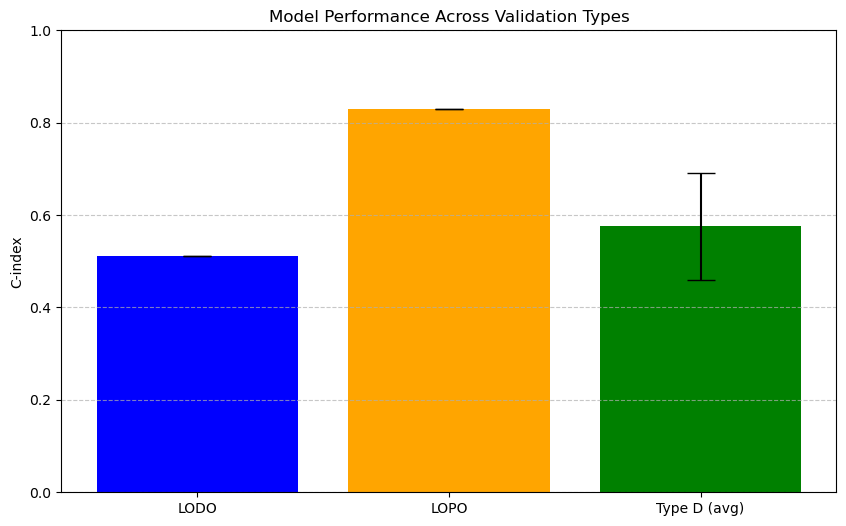


Type D Test Set Analysis:
Number of test pairs: 22
Unique proteins in test: 12
Unique drugs in test: 10


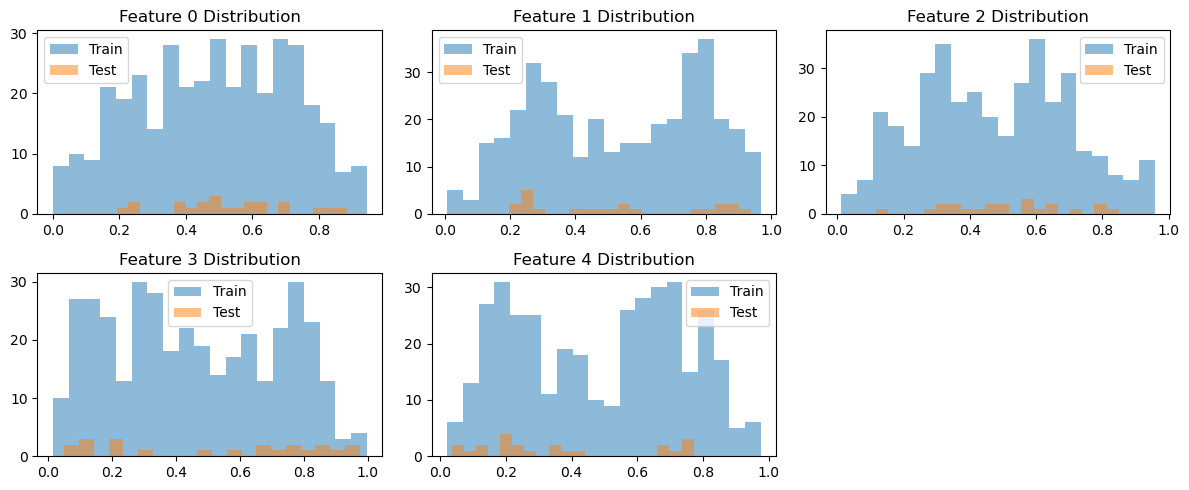

In [29]:
# Main execution with all validation types
X2, y2, pairs_df2 = load_data('input.data', 'output.data', 'pairs.data')

print('=' * 50)
print('COMPREHENSIVE MODEL VALIDATION')
print('=' * 50)

# 1. Type B (LODO)
print('\n1. Type B - Leave-One-Drug-Out (LODO)')
lodo_pred = lodo_cv(X2, y2, pairs_df2, k=10)
print(f"LODO C-index: {c_index(y2, lodo_pred):.4f}")

# 2. Type C (LOPO)
print('\n2. Type C - Leave-One-Protein-Out (LOPO)')
lopo_pred = lopo_cv(X2, y2, pairs_df2, k=10)
print(f"LOPO C-index: {c_index(y2, lopo_pred):.4f}")

# 3. Type D (unseen drug - unseen protein), repeated
print('\n3. Type D - Unseen Drug vs Unseen Protein')
type_d_scores, type_d_masks = repeated_type_d_cv(
    X2, y2, pairs_df2, n_repeats=5, test_size=0.2, k=10
)

# 4. Compare methods
plt.figure(figsize=(10, 6))
methods = ['LODO', 'LOPO', 'Type D (avg)']
scores = [
    c_index(y2, lodo_pred),
    c_index(y2, lopo_pred),
    np.mean(type_d_scores)
 ]
errors = [0, 0, np.std(type_d_scores)]

plt.bar(methods, scores, yerr=errors, capsize=10, color=['blue', 'orange', 'green'])
plt.ylabel('C-index')
plt.title('Model Performance Across Validation Types')
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. Analyze one Type D split in detail
_, _, test_mask_example = type_d_cv(
    X2, y2, pairs_df2, test_size=0.2, random_state=0, k=10
)
analyze_type_d_results(X2, y2, pairs_df2, test_mask_example)


Type D summary across repeats:
Mean C-index: 0.5757
Std C-index:  0.1163
Min C-index:  0.3464
Max C-index:  0.6677


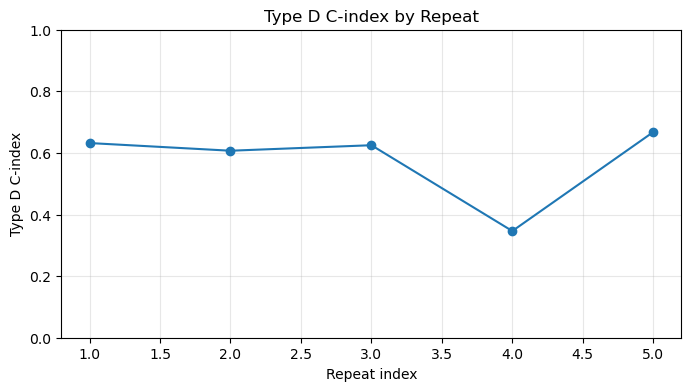

In [30]:
# Additional summary for repeated Type D
print('\nType D summary across repeats:')
print(f"Mean C-index: {np.mean(type_d_scores):.4f}")
print(f"Std C-index:  {np.std(type_d_scores):.4f}")
print(f"Min C-index:  {np.min(type_d_scores):.4f}")
print(f"Max C-index:  {np.max(type_d_scores):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(type_d_scores) + 1), type_d_scores, marker='o')
plt.xlabel('Repeat index')
plt.ylabel('Type D C-index')
plt.title('Type D C-index by Repeat')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

### Part 2 analysis of AI-generated code after revision


The updated implementation now uses split-based Type D validation: drugs and proteins are each split into train/test groups, and evaluation is done only on pairs where both entities are from the held-out groups. Training uses only train-drug and train-protein pairs. This directly matches the colleague scenario where both sides are unseen from the model's perspective.

To reduce randomness from one split, Type D is repeated multiple times with different random seeds and the mean plus standard deviation of C-index is reported. This gives a more stable estimate than a single random split and is more appropriate than pair-level leave-one-out for this assignment target.